# **# Data-Driven Hospital Operations & Patient Care Analytics Project**

## **Business Goal**

The hospital aims to leverage data-driven analysis to understand patient patterns, identify operational challenges, evaluate service performance, and improve overall financial visibility.

The key business questions are:

•	**Patient Profile**: 
     Who are our patients, and what are their key demographic characteristics?
•	**Operational Efficiency**: 
    Which departments experience the highest patient volumes and operational pressure?
•	**Waiting Time**:
    Where are significant waiting-time issues occurring across departments and visit types?
•	**Patient Satisfaction**: 
    How does waiting time influence patient satisfaction and overall visit experience?
•	**Patient Utilization**: 
    Which patient groups and demographic segments use hospital services most frequently?
•	**Financial Performance**: 
    Which service types and payer groups contribute to the highest financial burden?
•	**Management Action**: 
    What data-driven actions can management take to improve patient care, operational efficiency, and financial performance?

**Analytical Approach**:

Each analysis will follow a structured, business-oriented analytics workflow:
Business Problem → Analysis → Result → Observation → Insight → Recommendation
The recommendation will be developed only after evaluating the analytical results, ensuring that every proposed action is evidence-based, relevant to the identified business problem, and aligned with the hospital's operational and financial objectives.

## 1. Install Required Libraries

Before starting the analysis, install the required Python libraries and dependencies needed for data analysis and visualization.

In [54]:
#!pip install pandas

In [55]:
#!pip install matplotlib

In [56]:
#!pip install scipy

In [139]:
#!pip install seaborn

## 2. Import Libraries

Import the required libraries to support data loading, data cleaning, exploratory data analysis, statistical analysis, and visualization.
The required Python libraries are imported to support data loading, data cleaning, exploratory analysis, and statistical analysis throughout the project.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


### Import Data
The CSV datasets can be imported into Python using two common approaches:

**Method 1**: 
Import Using File Name
If the CSV files are stored in the same folder as the Jupyter Notebook, we can import them directly using their file names.
#billing = pd.read_csv('billing.csv', keep_default_na=False)

**Method 2**: 
Import Using the Full File Path
If the CSV files are stored in a different folder, we can provide the complete file path.
#billing = pd.read_csv(
    r"C:\Users\Veena Raghavendra\OneDrive\Desktop\Healthcareproject Anusha\billing.csv")

**Key Difference**
File name: Used when the dataset is available in the current working folder.
Full file path: Used when the dataset is stored in another location.
Both methods load the CSV data into a Pandas DataFrame and can be used for further analysis.

In [3]:
patients = pd.read_csv('patients.csv', keep_default_na=False)
visits = pd.read_csv('visits.csv', keep_default_na=False)
billing = pd.read_csv('billing.csv', keep_default_na=False)

print('Patients:', patients.shape)
print('Visits:', visits.shape)
print('Billing:', billing.shape)

Patients: (4010, 10)
Visits: (12015, 10)
Billing: (12015, 9)


In [59]:
patients

,patient_id,patient_name,gender,age,city,blood_group,insurance_status,chronic_condition,bmi,registration_date
0,100001,Patient_100001,Male,39,Hyderabad,,Insured,Nonevalue,30.9,20-11-2023
1,100002,Patient_100002,Male,49,Hyderabad,A+,Government Scheme,Thyroid,18.4,04-07-2023
2,100003,Patient_100003,Female,23,Karimnagar,B+,Insured,Nonevalue,17.8,24-06-2022
3,100004,Patient_100004,female,52,Secunderabad,O+,Insured,Cardiac,20.4,18-10-2025
4,100005,Patient_100005,Male,41,Nizamabad,O-,Insured,Diabetes,21.5,15-07-2022
...,...,...,...,...,...,...,...,...,...,...
4005,102449,Patient_102449,Male,44,Hyderabad,O+,Insured,Asthma,26.9,29-04-2023
4006,102939,Patient_102939,Female,45,Warangal,B-,Self Pay,Nonevalue,20.9,15-08-2022
4007,100814,Patient_100814,Female,58,Karimnagar,O+,Self Pay,Diabetes,21.4,02-03-2022
4008,101269,Patient_101269,Male,61,Warangal,,Self Pay,Nonevalue,30.1,19-06-2025


In [60]:
billing

,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,800001,500001,102866,7949.6,6172.69,1776.91,Scheme,Paid,2025-03-10
1,800002,500002,100602,1609.59,0.0,1609.59,Card,Paid,2025-01-23
2,800003,500003,102563,26915.56,22533.66,4381.9,Scheme,Partially Paid,2024-06-04
3,800004,500004,102617,20186.36,14645.71,5540.65,UPI,Paid,2024-06-30
4,800005,500005,100435,3098.79,2117.99,980.8,UPI,Paid,2025-04-11
...,...,...,...,...,...,...,...,...,...
12010,809240,509240,101130,4955.41,3571.01,1384.4,Insurance,Pending,2024-09-14
12011,810623,510623,103254,39663.59,32319.62,7343.97,Insurance,Paid,2025-12-29
12012,805563,505563,102576,4066.54,0.0,4066.54,Card,Paid,2025-01-18
12013,809389,509389,102954,2374.23,1881.12,493.11,UPI,Paid,2024-08-06


In [61]:
visits

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...
12010,503576,101896,2025-03-17,11,Pulmonology,COPD,OPD,54.0,0.0,4.8
12011,501412,100626,2025-05-08,14,General Medicine,Viral Infection,OPD,41.0,0.0,4.4
12012,502835,101751,2025-12-04,9,General Medicine,Diabetes Review,Inpatient,54.0,5.0,4.3
12013,503326,100096,2024-01-14,12,General Medicine,Viral Infection,Inpatient,63.0,3.0,4.5


In [4]:
billingstable = pd.read_csv(r"C:\Users\Veena Raghavendra\OneDrive\Desktop\Healthcareproject Anusha\billing.csv")

In [5]:
patientstable = pd.read_csv(r"C:\Users\Veena Raghavendra\OneDrive\Desktop\Healthcareproject Anusha\patients.csv")

In [6]:
visitstable = pd.read_csv(r"C:\Users\Veena Raghavendra\OneDrive\Desktop\Healthcareproject Anusha\visits.csv")

## 3. Basic Data Understanding

#### **Business Purpose**

Before performing data cleaning or analysis, it is important to understand the overall structure and quality of the datasets. This initial assessment helps identify potential data-quality issues and determines whether the data is suitable for further analysis.

The basic data understanding process focuses on:

**Dataset Size**: Identify the number of rows and columns in each dataset.
**Data Types**: Examine the data type of each column and verify whether it is appropriate for analysis.
**Missing Values**: Identify missing or blank values that may affect the accuracy of the analysis.
**Duplicate Records**: Detect duplicate records that could lead to incorrect counts, calculations, or insights.

This step provides a clear overview of the datasets before proceeding with **data cleaning, exploratory analysis, and business analysis**.

### Initial Dataset Inspection

The following code provides an initial overview of all three datasets. It displays the first few records using head() and provides structural information using info(), including the number of entries, column names, data types, and non-null values.

### Purpose of this step:

head() → Reviews the first few records of each dataset.
info() → Examines the dataset structure, column names, data types, and non-null values.
This initial inspection helps identify potential data-quality issues before proceeding with data cleaning and analysis.

In [7]:
print('\nPATIENTSTABLE')
display(patientstable.head())
patientstable.info()

print('\nVISITSTABLE')
display(visitstable.head())
visitstable.info()

print('\nBILLINGSTABLE')
display(billingstable.head())
billingstable.info()


PATIENTSTABLE


,patient_id,patient_name,gender,age,city,blood_group,insurance_status,chronic_condition,bmi,registration_date
0,100001,Patient_100001,Male,39,Hyderabad,NaN,Insured,Nonevalue,30.9,20-11-2023
1,100002,Patient_100002,Male,49,Hyderabad,A+,Government Scheme,Thyroid,18.4,04-07-2023
2,100003,Patient_100003,Female,23,Karimnagar,B+,Insured,Nonevalue,17.8,24-06-2022
3,100004,Patient_100004,female,52,Secunderabad,O+,Insured,Cardiac,20.4,18-10-2025
4,100005,Patient_100005,Male,41,Nizamabad,O-,Insured,Diabetes,21.5,15-07-2022


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4010 entries, 0 to 4009
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         4010 non-null   int64  
 1   patient_name       4010 non-null   object 
 2   gender             4010 non-null   object 
 3   age                4010 non-null   int64  
 4   city               3961 non-null   object 
 5   blood_group        3969 non-null   object 
 6   insurance_status   4010 non-null   object 
 7   chronic_condition  4010 non-null   object 
 8   bmi                3930 non-null   float64
 9   registration_date  4010 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 313.4+ KB

VISITSTABLE


,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12015 entries, 0 to 12014
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              12015 non-null  int64  
 1   patient_id            12015 non-null  int64  
 2   visit_date            12015 non-null  object 
 3   visit_hour            12015 non-null  int64  
 4   department            11975 non-null  object 
 5   diagnosis             11895 non-null  object 
 6   visit_type            12015 non-null  object 
 7   waiting_time_minutes  11835 non-null  float64
 8   length_of_stay_days   12015 non-null  float64
 9   satisfaction_score    11855 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 938.8+ KB

BILLINGSTABLE


,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,800001,500001,102866,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10
1,800002,500002,100602,1609.59,0.00,1609.59,Card,Paid,2025-01-23
2,800003,500003,102563,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04
3,800004,500004,102617,20186.36,14645.71,5540.65,UPI,Paid,2024-06-30
4,800005,500005,100435,3098.79,2117.99,980.80,UPI,Paid,2025-04-11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12015 entries, 0 to 12014
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bill_id                   12015 non-null  int64  
 1   visit_id                  12015 non-null  int64  
 2   patient_id                12015 non-null  int64  
 3   bill_amount               11865 non-null  float64
 4   insurance_covered_amount  11835 non-null  float64
 5   patient_paid_amount       11865 non-null  float64
 6   payment_method            11925 non-null  object 
 7   payment_status            12015 non-null  object 
 8   billing_date              12015 non-null  object 
dtypes: float64(3), int64(3), object(3)
memory usage: 844.9+ KB


### Convert Blank Values to Missing Values
Blank strings ('') in selected columns are converted to NaN so that they can be consistently identified and handled as missing values during the data-cleaning process.
Replace blank text with NaN only in columns where blanks were intentionally created

### Purpose:
Converts blank values into standard NaN missing values.
Applies the replacement only to the selected columns.
Makes missing-value detection and subsequent cleaning more reliable.

First, we checked the patientstable, visitstable and billingstable dataset for blank values. During the data-quality inspection, we identified blank text values.

Therefore, we specifically selected these columns and converted their blank strings into NaN.

In [8]:
patientstable[['bmi','city','blood_group']] = patientstable[['bmi','city','blood_group']].replace('', np.nan)

In [9]:
visitstable[['waiting_time_minutes','satisfaction_score','diagnosis','department']] = visitstable[['waiting_time_minutes','satisfaction_score','diagnosis','department']].replace('', np.nan)

In [10]:
billingstable[['bill_amount','insurance_covered_amount','patient_paid_amount','payment_method']] =     billingstable[['bill_amount','insurance_covered_amount','patient_paid_amount','payment_method']].replace('', np.nan)

In [11]:
patientstable.isnull().sum()

patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          41
insurance_status      0
chronic_condition     0
bmi                  80
registration_date     0
dtype: int64

In [13]:
visitstable.isnull().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department               40
diagnosis               120
visit_type                0
waiting_time_minutes    180
length_of_stay_days       0
satisfaction_score      160
dtype: int64

In [14]:
billingstable.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 150
insurance_covered_amount    180
patient_paid_amount         150
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

Convert Numeric Columns to Numeric Data Type

Some numeric columns may be imported as text because the CSV files can contain blank values or other non-numeric entries. To ensure accurate calculations and analysis, the relevant columns are explicitly converted to numeric data types.

In [15]:
patientstable['age'] = pd.to_numeric(patientstable['age'], errors='coerce')
patientstable['bmi'] = pd.to_numeric(patientstable['bmi'], errors='coerce')
visitstable['waiting_time_minutes'] = pd.to_numeric(visitstable['waiting_time_minutes'], errors='coerce')
visitstable['satisfaction_score'] = pd.to_numeric(visitstable['satisfaction_score'], errors='coerce')
visitstable['length_of_stay_days'] = pd.to_numeric(visitstable['length_of_stay_days'], errors='coerce')
billingstable['bill_amount'] = pd.to_numeric(billingstable['bill_amount'], errors='coerce')
billingstable['insurance_covered_amount'] = pd.to_numeric(billingstable['insurance_covered_amount'], errors='coerce')
billingstable['patient_paid_amount'] = pd.to_numeric(billingstable['patient_paid_amount'], errors='coerce')

## 4. Missing Values and Duplicate Audit
**Business Purpose**

Before proceeding with analysis, the datasets are systematically audited for missing values and duplicate records. These checks help ensure data quality and prevent incomplete or repeated records from affecting analytical results.

The audit focuses on:

Identifying missing values across all relevant columns.
Detecting blank values that may represent missing information.
Identifying duplicate records within each dataset.
Assessing the overall data quality before further analysis and transformation.

The findings from this audit will determine whether additional data-cleaning and validation steps are required.

In [16]:
print('Patients missing values')
display(patientstable.isna().sum())

print('Visits missing values')
display(visitstable.isna().sum())

print('Billing missing values')
display(billingstable.isna().sum())

print('Patient duplicates:', patientstable.duplicated().sum())
print('Visit duplicates:', visitstable.duplicated().sum())
print('Billing duplicates:', billingstable.duplicated().sum())

Patients missing values


patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          41
insurance_status      0
chronic_condition     0
bmi                  80
registration_date     0
dtype: int64

Visits missing values


visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department               40
diagnosis               120
visit_type                0
waiting_time_minutes    180
length_of_stay_days       0
satisfaction_score      160
dtype: int64

Billing missing values


bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 150
insurance_covered_amount    180
patient_paid_amount         150
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

Patient duplicates: 10
Visit duplicates: 15
Billing duplicates: 15


## 5. Data Cleaning
#### **Business Purpose**

Data cleaning is performed to improve the quality, consistency, and reliability of the datasets before analysis.

The cleaning process will be kept simple, targeted, and business-driven. Instead of applying the same cleaning rule to every column, the appropriate method will be selected based on the data type, business meaning, and relationship between related columns.

This approach helps preserve valid information while addressing only the data-quality issues that require correction.

#### 5.1 Clean Patient Data
##### Scenario 1 — Duplicate Records

Exact duplicate records can lead to overcounting patients and may distort demographic and utilization analysis. Therefore, exact duplicate rows should be identified and removed before further analysis.

Business Impact:
Removing exact duplicates ensures that patient-level counts and subsequent analysis are based on unique records.

In [17]:
patientstable = patientstable.drop_duplicates()

##### Scenario 2 — Standardize Gender and City

Inconsistent text formats can cause the same category to be treated as multiple categories. For example, Male, M, and male may represent the same gender but could be counted separately during analysis.

Similarly, differences in capitalization or formatting in city names can create unnecessary categories.

Business Impact:
Standardizing categorical values ensures consistent grouping, accurate counts, and reliable comparisons across patient demographics.

In [18]:
patientstable.head(5)

,patient_id,patient_name,gender,age,city,blood_group,insurance_status,chronic_condition,bmi,registration_date
0,100001,Patient_100001,Male,39,Hyderabad,NaN,Insured,Nonevalue,30.9,20-11-2023
1,100002,Patient_100002,Male,49,Hyderabad,A+,Government Scheme,Thyroid,18.4,04-07-2023
2,100003,Patient_100003,Female,23,Karimnagar,B+,Insured,Nonevalue,17.8,24-06-2022
3,100004,Patient_100004,female,52,Secunderabad,O+,Insured,Cardiac,20.4,18-10-2025
4,100005,Patient_100005,Male,41,Nizamabad,O-,Insured,Diabetes,21.5,15-07-2022


In [19]:
list_of_string_col = ['gender', 'city', 'blood_group', 'insurance_status', 'chronic_condition']

for col in list_of_string_col:
    print("The unique values in", col, patientstable[col].unique())

The unique values in gender ['Male' 'Female' 'female' 'FEMALE' 'M']
The unique values in city ['Hyderabad' 'Karimnagar' 'Secunderabad' 'Nizamabad' nan 'Warangal'
 'HYDERABAD' ' hyderabad ']
The unique values in blood_group [nan 'A+' 'B+' 'O+' 'O-' 'AB-' 'A-' 'AB+' 'B-']
The unique values in insurance_status ['Insured' 'Government Scheme' 'Self Pay']
The unique values in chronic_condition ['Nonevalue' 'Thyroid' 'Cardiac' 'Diabetes' 'Hypertension' 'Asthma']


In [20]:
patientstable['gender'].unique()

array(['Male', 'Female', 'female', 'FEMALE', 'M'], dtype=object)

In [21]:
patientstable['city'].unique()

array(['Hyderabad', 'Karimnagar', 'Secunderabad', 'Nizamabad', nan,
       'Warangal', 'HYDERABAD', ' hyderabad '], dtype=object)

In [22]:
patientstable['gender'] = patientstable['gender'].replace({
    'M':'Male',
    'female':'Female',
    'FEMALE':'Female'
})

In [23]:
patientstable['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [24]:
patientstable['city'] = patientstable['city'].str.strip().str.title()

.str.strip()   # Remove extra spaces and
.str.title()   # Standardize capitalization

In [25]:
patientstable['city'].unique()

array(['Hyderabad', 'Karimnagar', 'Secunderabad', 'Nizamabad', nan,
       'Warangal'], dtype=object)

##### Scenario 3 — Invalid Age

Age values below **1 year** or above **100 years** are considered invalid for this project and should be reviewed before analysis.

Rather than automatically replacing invalid values with the overall median age, we first examine whether patients with different chronic-condition groups have different age distributions.

This approach allows the replacement value to reflect the patient group’s age pattern, making the cleaning process more context-aware and reducing the risk of introducing bias into the analysis.

##### Identify Invalid Ages → Analyze Age Patterns by Chronic Condition → Select an Appropriate Group-Level Value → Replace Invalid Values → Validate the Result

In [26]:
patientstable.loc[(patientstable['age'] < 1) | (patientstable['age'] > 100), 'age'] 

45      125
193      -4
1021    125
1050     -4
1421     -4
1684     -4
2697    125
2803     -4
2891    125
2915    125
3084    125
3085     -4
3169     -4
3969    125
Name: age, dtype: int64

In [27]:
patientstable.loc[(patientstable['age'] < 1) | (patientstable['age'] > 100), 'age'] = np.nan


In [28]:
patientstable.loc[(patientstable['age'] < 1) | (patientstable['age'] > 100), 'age']

Series([], Name: age, dtype: float64)

In [29]:
display(
    patientstable.groupby('chronic_condition')['age']
            .median()
            .sort_values()
)

chronic_condition
Nonevalue       43.0
Asthma          44.0
Thyroid         49.0
Diabetes        51.0
Hypertension    54.0
Cardiac         56.0
Name: age, dtype: float64

**Cleaning Decision**

The analysis indicates that age distributions vary across chronic-condition groups. Therefore, missing or invalid age values will be imputed using the median age of the corresponding chronic-condition group.

This group-based approach preserves the underlying age patterns within each patient segment and provides a more context-appropriate replacement than applying a single overall median to all patients.

In [30]:
patientstable['chronic_condition'].unique()

array(['Nonevalue', 'Thyroid', 'Cardiac', 'Diabetes', 'Hypertension',
       'Asthma'], dtype=object)

#Impute missing age values using the median age of the corresponding chronic-condition group.

In [31]:
age_median = patientstable.groupby('chronic_condition')['age'].median()
for condition in patientstable['chronic_condition'].unique():
    value = age_median[condition]
    mask = (
        patientstable['age'].isna() &
        patientstable['chronic_condition'].eq(condition)
    )
    patientstable.loc[mask, 'age'] = value

In [32]:
patientstable['age'].isnull().sum()

np.int64(0)

#### Scenario 4 — Missing BMI

BMI can vary across different age groups. Therefore, instead of applying a single overall median BMI to all patients, we first segment patients into age groups.

Missing BMI values are then imputed using the median BMI of the corresponding age group. This group-based approach preserves the age-related patterns in the data and provides a more context-appropriate method for handling missing BMI values.

Create Age Groups → Calculate Group-Level Median BMI → Identify Missing BMI → Impute Using the Corresponding Age-Group Median → Validate

In [33]:
# Create age groups by categorizing patient ages into predefined ranges for age-group-based BMI analysis.
patientstable['age_group'] = pd.cut(
    patientstable['age'],
    bins=[0,17,30,45,60,100],
    labels=['0-17','18-30','31-45','46-60','60+']
)

In [34]:
patientstable.loc[(patientstable['bmi'] < 12) | (patientstable['bmi'] > 55), 'bmi'] = np.nan

In [35]:
bmi_median = patientstable.groupby('age_group')['bmi'].median()
for group in patientstable['age_group'].dropna().unique():
    mask = (
        patientstable['bmi'].isna() &
        patientstable['age_group'].eq(group)
    )
    patientstable.loc[mask, 'bmi'] = bmi_median[group]
patientstable['bmi'] = patientstable['bmi'].fillna(patientstable['bmi'].median())

C:\Users\Veena Raghavendra\AppData\Local\Temp\ipykernel_21324\2172043153.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_median = patientstable.groupby('age_group')['bmi'].median()


In [36]:
patientstable.isnull().sum()

patient_id            0
patient_name          0
gender                0
age                   0
city                 49
blood_group          40
insurance_status      0
chronic_condition     0
bmi                   0
registration_date     0
age_group             0
dtype: int64

#### Scenario 5 — Missing City and Blood Group

There is insufficient evidence to reliably infer missing city or blood group values from the available data. Therefore, instead of making assumptions or introducing potentially incorrect values, missing entries are explicitly labeled as Unknown.

This approach preserves data integrity and clearly distinguishes unknown information from known patient attributes.

In [37]:
patientstable['city'] = patientstable['city'].fillna('Unknown')
patientstable['blood_group'] = patientstable['blood_group'].fillna('Unknown')

In [38]:
patientstable['registration_date'] = pd.to_datetime(patientstable['registration_date'], errors='coerce')

C:\Users\Veena Raghavendra\AppData\Local\Temp\ipykernel_21324\4053408149.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  patientstable['registration_date'] = pd.to_datetime(patientstable['registration_date'], errors='coerce')


In [39]:
#cross check the patientstable data
patientstable

,patient_id,patient_name,gender,age,city,blood_group,insurance_status,chronic_condition,bmi,registration_date,age_group
0,100001,Patient_100001,Male,39.0,Hyderabad,Unknown,Insured,Nonevalue,30.9,2023-11-20,31-45
1,100002,Patient_100002,Male,49.0,Hyderabad,A+,Government Scheme,Thyroid,18.4,2023-07-04,46-60
2,100003,Patient_100003,Female,23.0,Karimnagar,B+,Insured,Nonevalue,17.8,2022-06-24,18-30
3,100004,Patient_100004,Female,52.0,Secunderabad,O+,Insured,Cardiac,20.4,2025-10-18,46-60
4,100005,Patient_100005,Male,41.0,Nizamabad,O-,Insured,Diabetes,21.5,2022-07-15,31-45
...,...,...,...,...,...,...,...,...,...,...,...
3995,103996,Patient_103996,Male,51.0,Secunderabad,A+,Insured,Hypertension,25.5,2024-02-26,46-60
3996,103997,Patient_103997,Male,40.0,Karimnagar,O-,Government Scheme,Diabetes,26.5,2025-03-01,31-45
3997,103998,Patient_103998,Female,76.0,Hyderabad,O+,Insured,Nonevalue,30.4,2023-08-15,60+
3998,103999,Patient_103999,Female,49.0,Nizamabad,A+,Self Pay,Cardiac,25.1,2025-02-21,46-60


In [122]:
patientstable.isnull().sum()

patient_id           0
patient_name         0
gender               0
age                  0
city                 0
blood_group          0
insurance_status     0
chronic_condition    0
bmi                  0
registration_date    0
age_group            0
dtype: int64

#### 5.2 Clean Visit Data

In [40]:
visitstable['visit_date'] = pd.to_datetime(visitstable['visit_date'], errors='coerce')
visitstable['department'] = visitstable['department'].str.strip().str.title()
# Standardize visit dates and department names to ensure consistent formatting for analysis.

In [41]:
visitstable.head()

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0


In [42]:
# Convert impossible values to missing first
visitstable.loc[visitstable['waiting_time_minutes'] <= 0, 'waiting_time_minutes'] = np.nan
visitstable.loc[(visitstable['satisfaction_score'] < 1) | (visitstable['satisfaction_score'] > 5), 'satisfaction_score'] = np.nan
visitstable.loc[visitstable['length_of_stay_days'] < 0, 'length_of_stay_days'] = np.nan

In [43]:
diagnosis_department = (
    visitstable.dropna(subset=['diagnosis','department'])
          .groupby('diagnosis')['department']
          .agg(lambda x: x.mode()[0])
)
#We use groupby to analyze each diagnosis separately and aggregate to identify its most common department

#### Scenario 6 - Missing Department

A patient’s diagnosis is generally associated with a specific department that provides the relevant treatment.
To handle missing department values:
This approach preserves the relationship between diagnosis and department while avoiding arbitrary value assignment.

#### Why this method?

If a diagnosis is usually handled by a particular department, using the most frequently associated department is more meaningful than filling all missing departments with one overall value.

Example:
If "Diabetes" appears mostly under "Endocrinology", a missing department for a Diabetes visit is filled with "Endocrinology".

In [48]:
diagnosis_department = (
    visitstable.dropna(subset=['diagnosis','department'])
          .groupby('diagnosis')['department']
          .agg(lambda x: x.mode()[0])
)

In [49]:
diagnosis_department

diagnosis
Allergy                          Pediatrics
Arrhythmia                       Cardiology
Arthritis                       Orthopedics
Asthma                          Pulmonology
Back Pain                       Orthopedics
COPD                            Pulmonology
Chest Pain                       Cardiology
Coronary Artery Disease          Cardiology
Diabetes Review            General Medicine
Fever                      General Medicine
Fracture                        Orthopedics
Gastritis                  General Medicine
Gastroenteritis                  Pediatrics
Hypertension                     Cardiology
Hypertension Review        General Medicine
Menstrual Disorder               Gynecology
PCOS                             Gynecology
Pneumonia                       Pulmonology
Pregnancy Review                 Gynecology
Respiratory Infection           Pulmonology
Sports Injury                   Orthopedics
UTI                              Gynecology
Viral Infection       

In [50]:
mask = visitstable['department'].isna() & visitstable['diagnosis'].notna()
visitstable.loc[mask, 'department'] = visitstable.loc[mask, 'diagnosis'].map(diagnosis_department)
visitstable['department'] = visitstable['department'].fillna('Unknown')

#We use this to fill missing departments based on their diagnosis, and mark unresolved values as "Unknown"

In [51]:
visitstable.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis               120
visit_type                0
waiting_time_minutes    192
length_of_stay_days       8
satisfaction_score      170
dtype: int64

In [52]:
department_diagnosis = (
    visitstable.dropna(subset=['diagnosis'])
          .groupby('department')['diagnosis']
          .agg(lambda x: x.mode()[0])
)

In [53]:
department_diagnosis

department
Cardiology          Coronary Artery Disease
General Medicine            Viral Infection
Gynecology               Menstrual Disorder
Orthopedics                        Fracture
Pediatrics                          Allergy
Pulmonology                            COPD
Name: diagnosis, dtype: object

In [54]:
visitstable['department'] = visitstable['department'].str.strip().str.title()

In [55]:
department_diagnosis = (
    visitstable.dropna(subset=['department', 'diagnosis'])
          .groupby('department')['diagnosis']
          .agg(lambda x: x.mode()[0])
)

print(department_diagnosis)

department
Cardiology          Coronary Artery Disease
General Medicine            Viral Infection
Gynecology               Menstrual Disorder
Orthopedics                        Fracture
Pediatrics                          Allergy
Pulmonology                            COPD
Name: diagnosis, dtype: object


In [56]:
mask = visitstable['diagnosis'].isna()

visitstable.loc[mask, 'diagnosis'] = visitstable.loc[mask, 'department'].map(department_diagnosis)

visitstable['diagnosis'] = visitstable['diagnosis'].fillna('Unknown')


In [57]:
visitstable.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis                 0
visit_type                0
waiting_time_minutes    192
length_of_stay_days       8
satisfaction_score      170
dtype: int64

#### Scenario 8 – Missing Waiting Time

Waiting time can vary depending on both the department and visit type. For example, waiting patterns in Cardiology OPD may differ from Emergency, while Pediatrics may have its own pattern.

To handle missing waiting-time values, calculate the median waiting time for each department and visit type combination and use the corresponding median to fill missing values.

This approach preserves department- and visit-type-specific waiting-time patterns and provides a more representative value than using an overall median.

In [58]:
wait_median = visitstable.groupby(
    ['department', 'visit_type']
)['waiting_time_minutes'].median()

In [59]:
wait_median

department        visit_type
Cardiology        Emergency     48.0
                  Inpatient     56.0
                  OPD           60.0
General Medicine  Emergency     40.5
                  Inpatient     48.0
                  OPD           52.0
Gynecology        Emergency     28.0
                  Inpatient     33.0
                  OPD           39.0
Orthopedics       Emergency     29.0
                  Inpatient     38.0
                  OPD           42.5
Pediatrics        Emergency     23.0
                  Inpatient     32.0
                  OPD           36.0
Pulmonology       Emergency     36.0
                  Inpatient     42.0
                  OPD           46.0
Name: waiting_time_minutes, dtype: float64

In [60]:
for department in visitstable['department'].unique():
    for visit_type in visitstable['visit_type'].unique():

        value = wait_median.get((department, visit_type))

        mask = (
            visitstable['waiting_time_minutes'].isna() &
            visitstable['department'].eq(department) &
            visitstable['visit_type'].eq(visit_type)
        )

        visitstable.loc[mask, 'waiting_time_minutes'] = value

visitstable['waiting_time_minutes'] =     visitstable['waiting_time_minutes'].fillna(
        visitstable['waiting_time_minutes'].median()
    )

In [61]:
visitstable.isna().sum()

visit_id                  0
patient_id                0
visit_date                0
visit_hour                0
department                0
diagnosis                 0
visit_type                0
waiting_time_minutes      0
length_of_stay_days       8
satisfaction_score      170
dtype: int64

#### Scenario 9 – Missing Satisfaction

Patient satisfaction can vary based on the waiting time experienced and the department providing the service.

To handle missing satisfaction values:

Create meaningful waiting-time bands.
Calculate the median satisfaction score for each department and waiting-time band.
Use the corresponding median satisfaction score to fill missing values.

This approach preserves the relationship between department, waiting time, and patient satisfaction.

In [62]:
visitstable['wait_band'] = pd.cut(
    visitstable['waiting_time_minutes'],
    bins=[0,20,40,60,10000],
    labels=['<=20','21-40','41-60','60+']
)

In [63]:
satisfaction_median = visitstable.groupby(
    ['department','wait_band'])['satisfaction_score'].median()

satisfaction_median

C:\Users\Veena Raghavendra\AppData\Local\Temp\ipykernel_21324\1381954121.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_median = visitstable.groupby(


department        wait_band
Cardiology        <=20         4.90
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
General Medicine  <=20         4.80
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
Gynecology        <=20         4.80
                  21-40        4.60
                  41-60        4.40
                  60+          4.00
Orthopedics       <=20         4.80
                  21-40        4.60
                  41-60        4.30
                  60+          4.05
Pediatrics        <=20         4.80
                  21-40        4.60
                  41-60        4.40
                  60+          4.10
Pulmonology       <=20         4.90
                  21-40        4.60
                  41-60        4.30
                  60+          4.10
Name: satisfaction_score, dtype: float64

In [64]:
for department in visitstable['department'].unique():
    for band in visitstable['wait_band'].dropna().unique():
        value = satisfaction_median.get((department, band))
        mask = (
            visitstable['satisfaction_score'].isna() &
            visitstable['department'].eq(department) &
            visitstable['wait_band'].eq(band)
        )
        visitstable.loc[mask, 'satisfaction_score'] = value
visitstable['satisfaction_score'] = visitstable['satisfaction_score'].fillna(
        visitstable['satisfaction_score'].median()
    )

In [65]:
# cross check 
visitstable.isnull().sum()

visit_id                0
patient_id              0
visit_date              0
visit_hour              0
department              0
diagnosis               0
visit_type              0
waiting_time_minutes    0
length_of_stay_days     8
satisfaction_score      0
wait_band               0
dtype: int64

#### 5.3 Clean Billing Data

In [66]:
billingstable = billingstable.drop_duplicates().copy()
billingstable['billing_date'] = pd.to_datetime(
    billingstable['billing_date'],
    errors='coerce'
)

In [67]:
billingstable.head(5)

,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,800001,500001,102866,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10
1,800002,500002,100602,1609.59,0.00,1609.59,Card,Paid,2025-01-23
2,800003,500003,102563,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04
3,800004,500004,102617,20186.36,14645.71,5540.65,UPI,Paid,2024-06-30
4,800005,500005,100435,3098.79,2117.99,980.80,UPI,Paid,2025-04-11


In [68]:
billingstable['payment_method'].unique()

array(['Scheme', 'Card', 'UPI', 'Cash', 'Insurance', nan], dtype=object)

In [69]:
billingstable['payment_method'] = billingstable['payment_method'].str.strip().str.title()

In [70]:
billingstable.loc[billingstable['bill_amount'] <= 0, 'bill_amount']

126    -500.0
626    -500.0
716    -500.0
6353   -500.0
6797   -500.0
6933   -500.0
8037   -500.0
9571   -500.0
Name: bill_amount, dtype: float64

In [71]:
billingstable.loc[billingstable['patient_paid_amount'] < 0, 'patient_paid_amount']

874     -100.0
2057    -100.0
2613    -100.0
5639    -100.0
5930    -100.0
7176    -100.0
9368    -100.0
10818   -100.0
Name: patient_paid_amount, dtype: float64

In [72]:
billingstable.loc[billingstable['bill_amount'] <= 0, 'bill_amount'] = np.nan
billingstable.loc[billingstable['patient_paid_amount'] < 0, 'patient_paid_amount'] = np.nan

In [73]:
billingstable.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                 158
insurance_covered_amount    180
patient_paid_amount         158
payment_method               90
payment_status                0
billing_date                  0
dtype: int64

#### Scenario 10 – Missing Bill Amount

Bill amount can vary significantly depending on the department and visit type.
To handle missing bill amounts:

Bring the department and visit type information from the Visits table using the visit ID.
Calculate the median bill amount for each department and visit-type combination.
Use the corresponding median to fill missing bill amounts.

This approach provides a more representative estimate based on the specific service combination.

In [74]:
billingstable = billingstable.merge(
    visitstable[['visit_id','department','visit_type']],
    on='visit_id',
    how='left'
)

In [75]:
bill_median = billingstable.groupby(
    ['department','visit_type']
)['bill_amount'].median()
bill_median

department        visit_type
Cardiology        Emergency      7637.890
                  Inpatient     32958.105
                  OPD            3747.560
General Medicine  Emergency      2566.115
                  Inpatient     23002.060
                  OPD            1308.600
Gynecology        Emergency      4539.935
                  Inpatient     26307.570
                  OPD            2347.830
Orthopedics       Emergency      6050.125
                  Inpatient     28384.460
                  OPD            3085.245
Pediatrics        Emergency      2888.870
                  Inpatient     22680.575
                  OPD            1407.580
Pulmonology       Emergency      4965.260
                  Inpatient     26927.060
                  OPD            2460.340
Name: bill_amount, dtype: float64

In [76]:
for department in billingstable['department'].unique():
    for visit_type in billingstable['visit_type'].unique():

        value = bill_median.get((department, visit_type))

        mask = (
            billingstable['bill_amount'].isna() &
            billingstable['department'].eq(department) &
            billingstable['visit_type'].eq(visit_type)
        )

        billingstable.loc[mask, 'bill_amount'] = value

billingstable['bill_amount'] = billingstable['bill_amount'].fillna(billingstable['bill_amount'].median())

In [78]:
billingstable.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount    180
patient_paid_amount         159
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
dtype: int64

#### Scenario 11 – Missing Insurance Coverage

Insurance coverage depends on the patient’s insurance status.

To handle missing insurance coverage values:

Bring the insurance status from the Patients table.
Apply the following business rules:
Self Pay → Insurance coverage = 0
Insured / Government Scheme → Use the typical coverage percentage for the same payer group.

This approach ensures that insurance coverage is estimated according to the patient’s insurance status and payer group.

In [79]:
billingstable = billingstable.merge(
    patientstable[['patient_id','insurance_status']],
    on='patient_id',
    how='left'
)

In [80]:
mask = (
    billingstable['insurance_covered_amount'].isna() &
    billingstable['insurance_status'].eq('Self Pay')
)
billingstable.loc[mask, 'insurance_covered_amount']

185     NaN
646     NaN
853     NaN
960     NaN
1400    NaN
         ..
10900   NaN
11262   NaN
11482   NaN
11505   NaN
11770   NaN
Name: insurance_covered_amount, Length: 61, dtype: float64

In [81]:
mask = (
    billingstable['insurance_covered_amount'].isna() &
    billingstable['insurance_status'].eq('Self Pay')
)
billingstable.loc[mask, 'insurance_covered_amount'] = 0

In [82]:
billingstable.isna().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount    119
patient_paid_amount         159
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
dtype: int64

In [83]:
billingstable['coverage_pct'] = (
    billingstable['insurance_covered_amount'] /
    billingstable['bill_amount']
)
billingstable.head()

,bill_id,visit_id,patient_id,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date,department,visit_type,insurance_status,coverage_pct
0,800001,500001,102866,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10,General Medicine,Inpatient,Government Scheme,0.776478
1,800002,500002,100602,1609.59,0.00,1609.59,Card,Paid,2025-01-23,General Medicine,OPD,Self Pay,0.000000
2,800003,500003,102563,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04,Orthopedics,Inpatient,Government Scheme,0.837198
3,800004,500004,102617,20186.36,14645.71,5540.65,Upi,Paid,2024-06-30,Gynecology,Inpatient,Insured,0.725525
4,800005,500005,100435,3098.79,2117.99,980.80,Upi,Paid,2025-04-11,General Medicine,Emergency,Insured,0.683489


In [84]:
coverage_median = billingstable.groupby(
    'insurance_status'
)['coverage_pct'].median()
coverage_median

insurance_status
Government Scheme    0.824150
Insured              0.684064
Self Pay             0.000000
Name: coverage_pct, dtype: float64

In [85]:
# Government Scheme	82.42%
# Insured	68.41%
# Self Pay	0%

In [86]:
for payer in ['Insured','Government Scheme']:
    mask = (
        billingstable['insurance_covered_amount'].isna() &
        billingstable['insurance_status'].eq(payer)
    )
    billingstable.loc[mask, 'insurance_covered_amount'] = (
        billingstable.loc[mask, 'bill_amount'] *coverage_median[payer]
    )
billingstable['insurance_covered_amount'] = billingstable['insurance_covered_amount'].fillna(0)

In [88]:
billingstable.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount      0
patient_paid_amount         159
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
coverage_pct                119
dtype: int64

#### Scenario 12 – Missing Patient Paid Amount

Patient paid amount can be calculated directly from the available billing values.

**Formula:**
Patient Paid Amount = Total Bill Amount − Insurance Covered Amount

This is more accurate than using a mean or median because the value can be derived directly from the actual bill and insurance coverage.

In [89]:
mask = billingstable['patient_paid_amount'].isna()
billingstable.loc[mask, 'patient_paid_amount']

21      NaN
71      NaN
104     NaN
138     NaN
180     NaN
         ..
11689   NaN
11828   NaN
11841   NaN
11873   NaN
11897   NaN
Name: patient_paid_amount, Length: 159, dtype: float64

In [90]:
mask = billingstable['patient_paid_amount'].isna()
billingstable.loc[mask, 'patient_paid_amount'] = (
    billingstable.loc[mask, 'bill_amount'] -
    billingstable.loc[mask, 'insurance_covered_amount']
)
billingstable['patient_paid_amount'] = billingstable['patient_paid_amount'].clip(lower=0)


In [91]:
billingstable.isnull().sum()

bill_id                       0
visit_id                      0
patient_id                    0
bill_amount                   0
insurance_covered_amount      0
patient_paid_amount           0
payment_method               90
payment_status                0
billing_date                  0
department                    0
visit_type                    0
insurance_status              0
coverage_pct                119
dtype: int64

## 6. Merge the Three Tables

Visits is the main transaction table because each record represents a patient visit. The Patients and Billing tables are merged with Visits using their respective key columns to create a single dataset for analysis.

In [92]:
df = visitstable.merge(
    patientstable,
    on='patient_id',
    how='left'
)

In [93]:
df = df.merge(
    billingstable[
        ['visit_id','patient_id','bill_amount',
         'insurance_covered_amount','patient_paid_amount',
         'payment_method','payment_status','billing_date']
    ],
    on=['visit_id','patient_id'],
    how='left'
)
print(df.shape)
display(df.head())

(12045, 27)


,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,chronic_condition,bmi,registration_date,age_group,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,Nonevalue,28.8,2025-02-19,18-30,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,Nonevalue,17.0,2022-02-12,60+,1609.59,0.00,1609.59,Card,Paid,2025-01-23
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0,...,Nonevalue,24.3,2025-01-18,46-60,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0,...,Nonevalue,25.3,2023-10-10,31-45,20186.36,14645.71,5540.65,Upi,Paid,2024-06-30
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0,...,Asthma,28.2,2025-03-04,46-60,3098.79,2117.99,980.80,Upi,Paid,2025-04-11


## 7. Feature Engineering

Creating a new meaningful features from the existing data to support deeper analysis and generate business insights.

In [94]:
df['visit_day'] = df['visit_date'].dt.day_name()
df['visit_month'] = df['visit_date'].dt.to_period('M').astype(str)
# cross check 
df.head(3)

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,registration_date,age_group,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date,visit_day,visit_month
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,2025-02-19,18-30,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10,Friday,2025-03
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,2022-02-12,60+,1609.59,0.00,1609.59,Card,Paid,2025-01-23,Wednesday,2025-01
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0,...,2025-01-18,46-60,26915.56,22533.66,4381.90,Scheme,Partially Paid,2024-06-04,Tuesday,2024-06


In [95]:
df['visit_time_band'] = pd.cut(
    df['visit_hour'],
    bins=[0,6,11,16,20,24],
    labels=['Night','Morning','Midday','Evening','Late Evening'],
    right=False
)

In [96]:
df['out_of_pocket_pct'] = (
    df['patient_paid_amount'] / df['bill_amount'] * 100).round(1)

# cross chekc 
df.head(2)

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,bill_amount,insurance_covered_amount,patient_paid_amount,payment_method,payment_status,billing_date,visit_day,visit_month,visit_time_band,out_of_pocket_pct
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,7949.60,6172.69,1776.91,Scheme,Paid,2025-03-10,Friday,2025-03,Midday,22.4
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,1609.59,0.00,1609.59,Card,Paid,2025-01-23,Wednesday,2025-01,Midday,100.0


In [97]:
df['high_wait_flag'] = np.where(
    df['waiting_time_minutes'] > 60,
    'High Wait',
    'Normal Wait'
)

In [98]:
patient_visit_count = df.groupby(
    'patient_id'
)['visit_id'].transform('count')
patient_visit_count

0        6
1        3
2        2
3        5
4        2
        ..
12040    5
12041    6
12042    6
12043    7
12044    7
Name: visit_id, Length: 12045, dtype: int64

In [99]:
df['repeat_patient'] = np.where(
    patient_visit_count > 1,
    'Repeat',
    'Single Visit'
)

In [100]:
df.head()

,visit_id,patient_id,visit_date,visit_hour,department,diagnosis,visit_type,waiting_time_minutes,length_of_stay_days,satisfaction_score,...,patient_paid_amount,payment_method,payment_status,billing_date,visit_day,visit_month,visit_time_band,out_of_pocket_pct,high_wait_flag,repeat_patient
0,500001,102866,2025-03-07,11,General Medicine,Hypertension Review,Inpatient,44.0,1.0,4.7,...,1776.91,Scheme,Paid,2025-03-10,Friday,2025-03,Midday,22.4,Normal Wait,Repeat
1,500002,100602,2025-01-22,13,General Medicine,Diabetes Review,OPD,60.0,0.0,4.4,...,1609.59,Card,Paid,2025-01-23,Wednesday,2025-01,Midday,100.0,Normal Wait,Repeat
2,500003,102563,2024-06-04,16,Orthopedics,Sports Injury,Inpatient,28.0,3.0,5.0,...,4381.90,Scheme,Partially Paid,2024-06-04,Tuesday,2024-06,Evening,16.3,Normal Wait,Repeat
3,500004,102617,2024-06-29,7,Gynecology,PCOS,Inpatient,27.0,4.0,5.0,...,5540.65,Upi,Paid,2024-06-30,Saturday,2024-06,Morning,27.4,Normal Wait,Repeat
4,500005,100435,2025-04-08,15,General Medicine,Fever,Emergency,37.0,0.0,5.0,...,980.80,Upi,Paid,2025-04-11,Tuesday,2025-04,Midday,31.7,Normal Wait,Repeat


In [101]:
df['chronic_condition'].unique()

array(['Nonevalue', 'Asthma', 'Hypertension', 'Diabetes', 'Thyroid',
       'Cardiac'], dtype=object)

## **PART A – UNIVARIATE ANALYSIS**

Univariate analysis examines one variable at a time to understand its distribution, patterns, and characteristics.
We first analyze the variable and then determine whether the observed pattern has any business relevance or operational significance.

### Business Question: Which age group accounts for the highest number of hospital visits?

In [102]:
age_analysis = df['age_group'].value_counts().sort_index()
display(age_analysis)

age_group
0-17      545
18-30    1586
31-45    3527
46-60    3697
60+      2690
Name: count, dtype: int64

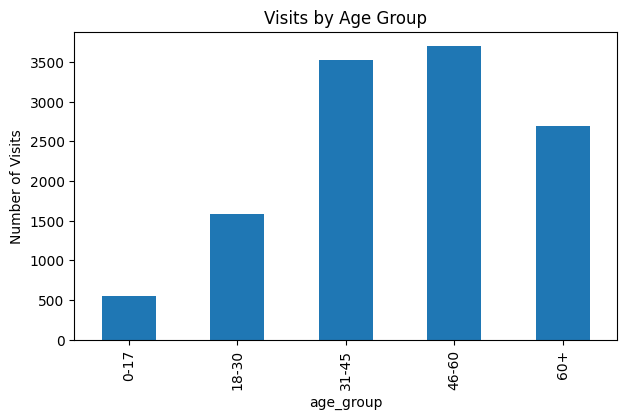

In [103]:
plt.figure(figsize=(7,4))
age_analysis.plot(kind='bar')
plt.title('Visits by Age Group')
plt.ylabel('Number of Visits')
plt.show()

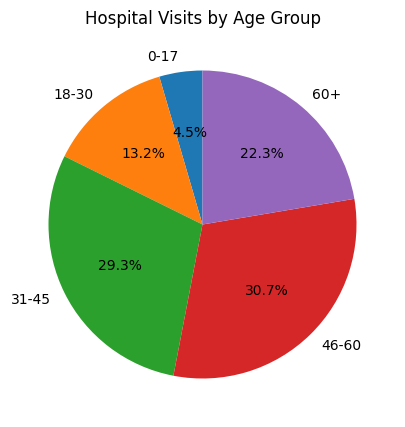

In [143]:
plt.figure(figsize=(7, 5))
age_analysis.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Hospital Visits by Age Group')
plt.ylabel('')
plt.show()

#### Observation

The 46–60 age group records the highest number of hospital visits, with approximately 3,697 visits.

#### Insight

The high visit volume indicates that middle-aged and older adults represent a significant portion of hospital demand. This may reflect a greater need for ongoing treatment, routine health monitoring, and management of age-related health conditions.

#### Business Recommendation
Ensure adequate availability of chronic-care management and preventive-health services for this high-utilization age group.
Strengthen routine screening and health-monitoring programs to support early identification of health risks.
Plan staffing, appointment capacity, and clinical resources according to the higher demand from this age group.
Monitor age-group visit trends regularly to identify changes in patient demand and adjust resources accordingly.

### Business Question2: Which chronic conditions are most commonly observed among the hospital’s patients?

In [104]:
chronic_analysis = df['chronic_condition'].value_counts()
display(chronic_analysis)

chronic_condition
Nonevalue       5457
Hypertension    2250
Diabetes        1950
Asthma           909
Cardiac          822
Thyroid          657
Name: count, dtype: int64

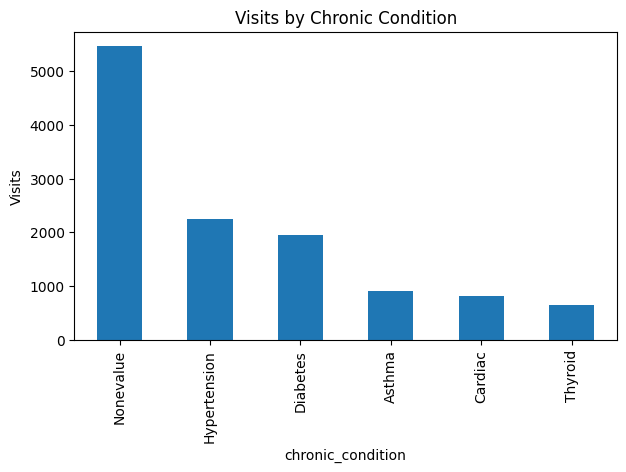

In [105]:
plt.figure(figsize=(7,4))
chronic_analysis.plot(kind='bar')
plt.title('Visits by Chronic Condition')
plt.ylabel('Visits')
plt.show()


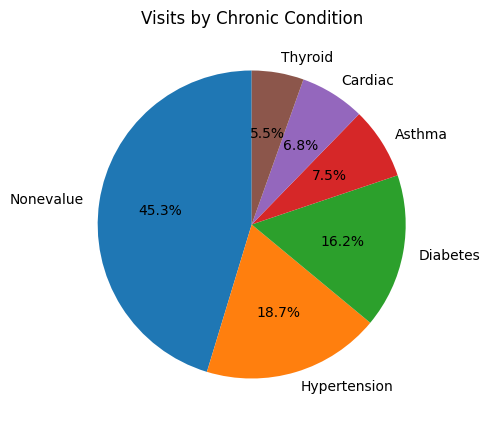

In [146]:
plt.figure(figsize=(7,5))
chronic_analysis.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Visits by Chronic Condition')
plt.ylabel('')
plt.show()

#### Observation

Excluding patients with “None” as their chronic condition, Hypertension appears most frequently, with approximately 2,226 visits.

#### Insight

The hospital experiences recurring demand related to chronic disease management, particularly for hypertension.

#### Business Recommendation
Strengthen follow-up programs for patients with common chronic conditions.
Plan appointments and clinical resources based on recurring chronic-care demand.

### Business Question3: What proportion of patients falls under each insurance status?

In [106]:
df['insurance_status'].value_counts()

insurance_status
Insured              6008
Self Pay             3904
Government Scheme    2133
Name: count, dtype: int64

In [107]:
df['insurance_status'].value_counts(normalize=True) * 100

insurance_status
Insured              49.879618
Self Pay             32.411789
Government Scheme    17.708593
Name: proportion, dtype: float64

In [108]:
insurance_analysis = (df['insurance_status'].value_counts(normalize=True).mul(100).round(1))

display(insurance_analysis)

insurance_status
Insured              49.9
Self Pay             32.4
Government Scheme    17.7
Name: proportion, dtype: float64

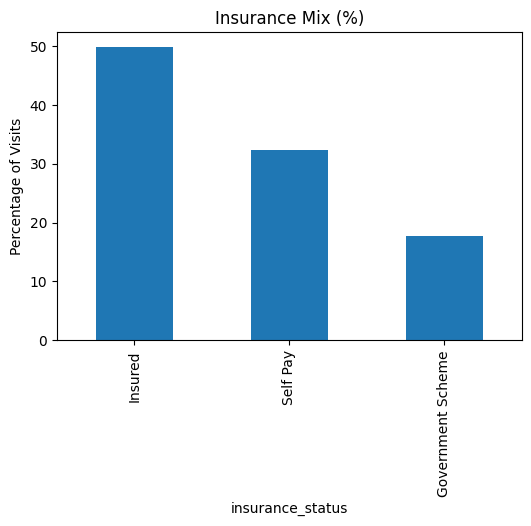

In [109]:
plt.figure(figsize=(6,4))
insurance_analysis.plot(kind='bar')
plt.title('Insurance Mix (%)')
plt.ylabel('Percentage of Visits')
plt.show()

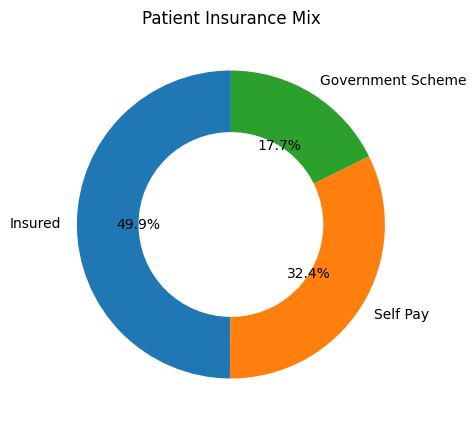

In [113]:
plt.figure(figsize=(6,5))
insurance_analysis.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title('Patient Insurance Mix')
plt.ylabel('')
plt.show()

#### Observation

Insured is the largest payer group, representing approximately 49.9% of visits.

#### Insight

The high proportion of insured patients indicates that the hospital's financial performance is significantly influenced by its payer mix, including insurance coverage and reimbursement patterns.

#### Business Recommendation
Track revenue and outstanding payments separately for each insurance category.
Monitor insurance claim processing and reimbursement patterns to identify payment delays.
Track patient contribution amounts across payer groups to understand the hospital's financial inflows.

### Business Question4: How long do patients typically wait, and how significant is the waiting-time problem across the hospital?

In [114]:
print(df['waiting_time_minutes'].describe().round(2))

count    12045.00
mean        45.39
std         19.06
min          5.00
25%         34.00
50%         44.00
75%         55.00
max        244.00
Name: waiting_time_minutes, dtype: float64


In [153]:
244/60

4.066666666666666

In [115]:
wait_percentage = (
    df['wait_band']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

display(wait_percentage)

wait_band
41-60    45.4
21-40    33.2
60+      15.2
<=20      6.2
Name: proportion, dtype: float64

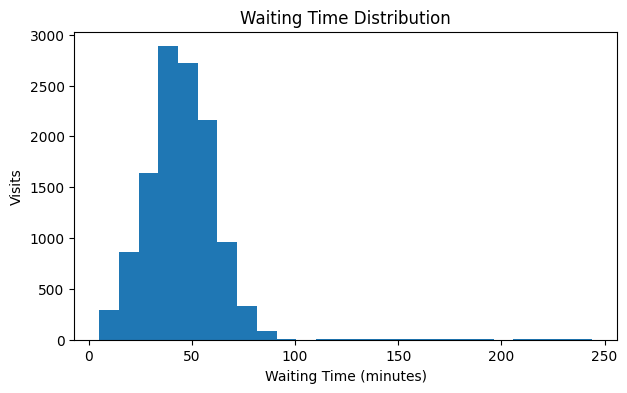

In [116]:
plt.figure(figsize=(7,4))
plt.hist(df['waiting_time_minutes'], bins=25)
plt.title('Waiting Time Distribution')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Visits')
plt.show()

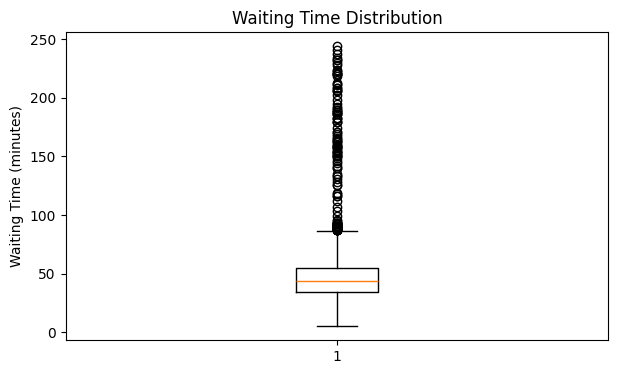

In [117]:
plt.figure(figsize=(7,4))
plt.boxplot(df['waiting_time_minutes'].dropna())
plt.title('Waiting Time Distribution')
plt.ylabel('Waiting Time (minutes)')
plt.show()

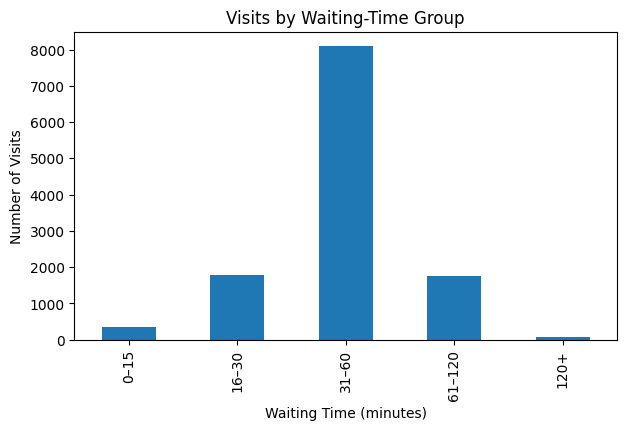

In [118]:
df['waiting_group'] = pd.cut(
    df['waiting_time_minutes'],
    bins=[0, 15, 30, 60, 120, float('inf')],
    labels=['0–15', '16–30', '31–60', '61–120', '120+']
)
waiting_analysis = df['waiting_group'].value_counts().sort_index()
plt.figure(figsize=(7,4))
waiting_analysis.plot(kind='bar')
plt.title('Visits by Waiting-Time Group')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Number of Visits')
plt.show()

### Observation

The average waiting time is 45.4 minutes, while the median waiting time is 44.5 minutes. Approximately 15.2% of visits involve waiting for more than 60 minutes.

### Insight

The waiting-time issue affects a noticeable proportion of patients, with around 1 in 7 visits experiencing waits longer than one hour.

### Business Recommendation
Track both average waiting time and the percentage of visits exceeding 60 minutes as key operational metrics.
Identify departments and visit types with consistently higher waiting times.
Review staffing, appointment scheduling, and patient flow in high-waiting areas.

### Business Question5: Which city contributes the highest number of hospital visits?

In [119]:
city_analysis = df['city'].value_counts()
display(city_analysis)

city
Hyderabad       5243
Secunderabad    2040
Warangal        1792
Karimnagar      1529
Nizamabad       1317
Unknown          124
Name: count, dtype: int64

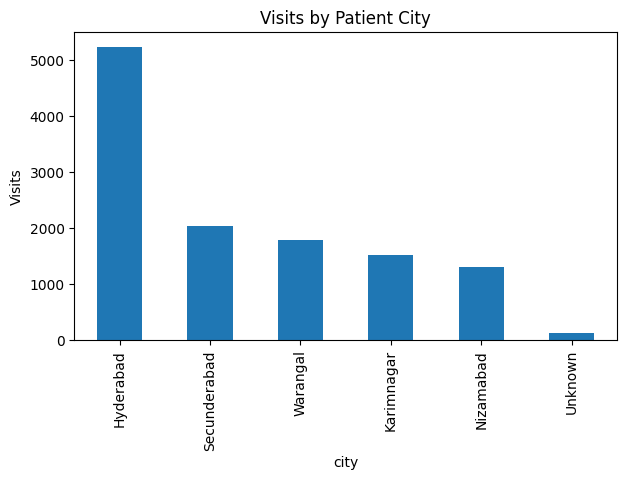

In [120]:
plt.figure(figsize=(7,4))
city_analysis.head(6).plot(kind='bar')
plt.title('Visits by Patient City')
plt.ylabel('Visits')
plt.show()

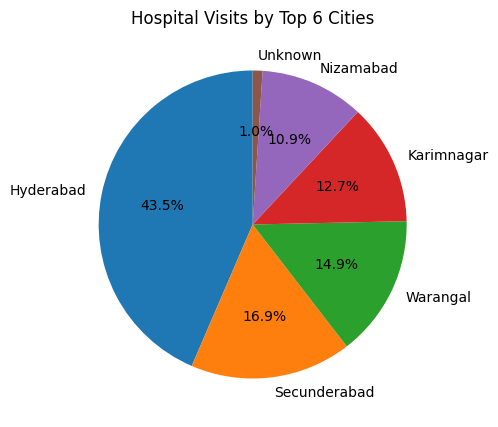

In [121]:
plt.figure(figsize=(7,5))
city_analysis.head(6).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Hospital Visits by Top 6 Cities')
plt.ylabel('')
plt.show()

#### Observation

Hyderabad contributes the highest number of hospital visits, with approximately 5,225 visits.

#### Insight

The high visit volume indicates that Hyderabad is a major patient catchment area for the hospital and represents a significant source of patient demand.

#### Business Recommendation

Use city-level demand patterns to support outreach clinic planning, targeted patient engagement, and future service expansion decisions.

## **PART B – BIVARIATE ANALYSIS**

Bivariate analysis examines the relationship between two variables to understand how one variable changes in relation to another.

It helps identify patterns, differences, and relationships between business factors and supports deeper business insights.

### Business Question6: Which department has the highest average waiting time?

In [166]:
department_wait = (
    df.groupby('department')['waiting_time_minutes']
      .agg(['count','mean','median'])
      .round(2)
      .sort_values('mean', ascending=False)
)
display(department_wait)

,count,mean,median
department,,,
Cardiology,1917,58.89,58.0
General Medicine,3559,49.82,49.0
Pulmonology,1637,44.36,44.0
Orthopedics,1982,40.35,40.0
Gynecology,1492,37.01,36.0
Pediatrics,1458,33.40,33.0


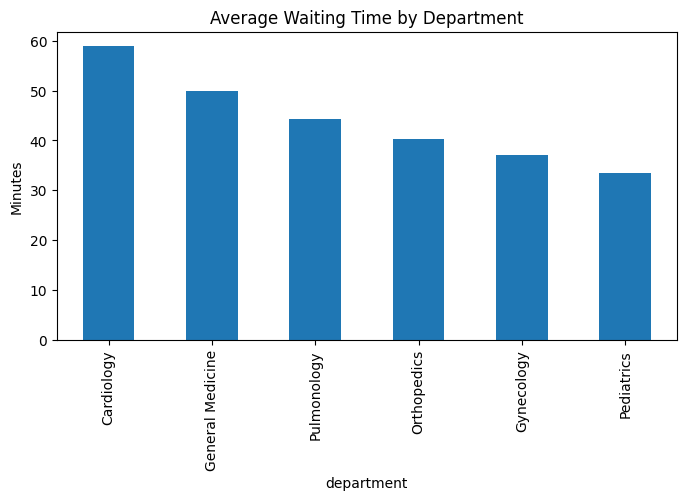

In [167]:
plt.figure(figsize=(8,4))
department_wait['mean'].plot(kind='bar')
plt.title('Average Waiting Time by Department')
plt.ylabel('Minutes')
plt.show()

<Figure size 800x500 with 0 Axes>

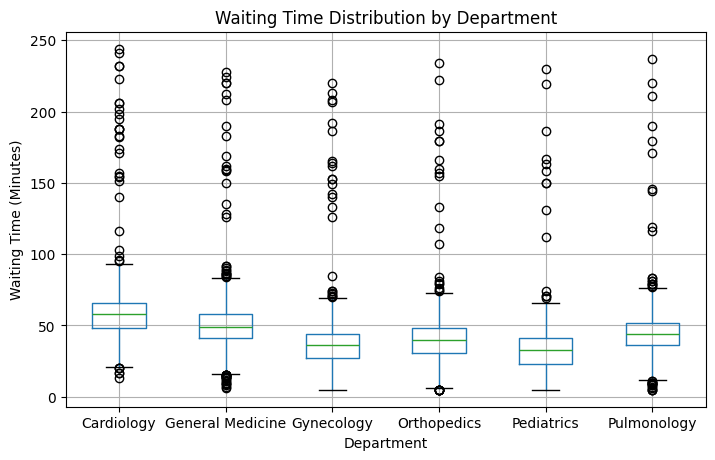

In [168]:
plt.figure(figsize=(8,5))
df.boxplot(
    column='waiting_time_minutes',
    by='department',
    figsize=(8,5)
)
plt.title('Waiting Time Distribution by Department')
plt.suptitle('')
plt.xlabel('Department')
plt.ylabel('Waiting Time (Minutes)')
plt.show()

### Observation

Cardiology has the highest average waiting time at approximately 58.9 minutes, compared with the other departments.

### Insight

The higher waiting time in Cardiology indicates potential operational pressure or patient-flow challenges within the department.

### Business Recommendation

Review appointment scheduling, doctor availability, and registration and patient-flow processes in Cardiology to identify factors contributing to longer waiting times and improve service efficiency.

### Business Question7: Which department handles the highest number of patient visits?

In [170]:
department_volume = (
    df['department']
    .value_counts()
)
display(department_volume)

department
General Medicine    3559
Orthopedics         1982
Cardiology          1917
Pulmonology         1637
Gynecology          1492
Pediatrics          1458
Name: count, dtype: int64

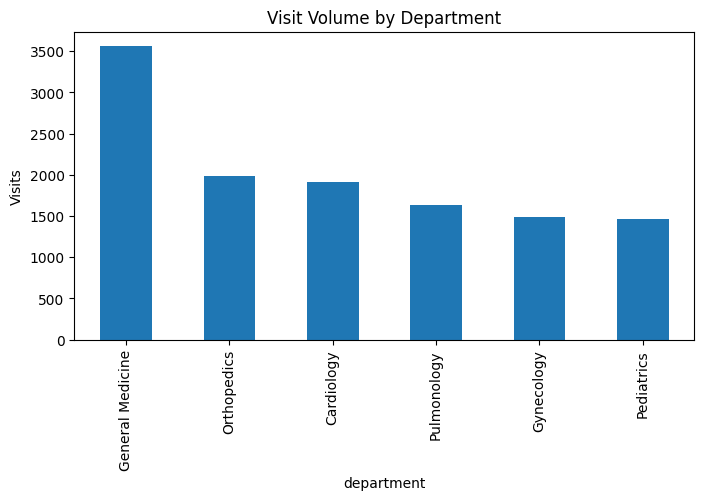

In [171]:
plt.figure(figsize=(8,4))
department_volume.plot(kind='bar')
plt.title('Visit Volume by Department')
plt.ylabel('Visits')
plt.show()

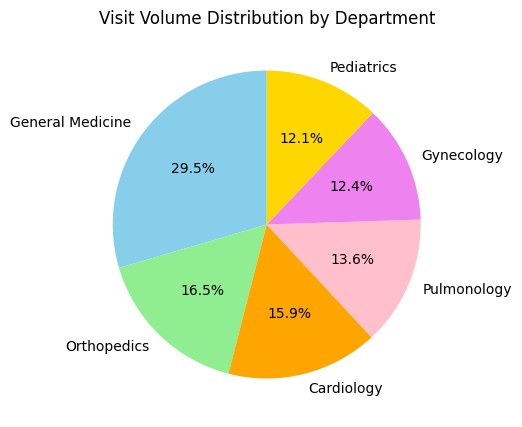

In [173]:
plt.figure(figsize=(7,5))
department_volume.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightgreen', 'orange', 'pink', 'violet', 'gold']
)
plt.title('Visit Volume Distribution by Department')
plt.ylabel('')
plt.show()

#### Observation

General Medicine handles the highest patient volume, with approximately 3,559 visits.

#### Insight

The high patient volume indicates that General Medicine is a major source of hospital demand. While high volume does not necessarily indicate poor performance, it can place greater pressure on staffing, appointment capacity, and queue management.

#### Business Recommendation

Use department patient volume together with waiting-time metrics when planning staffing and operational capacity. Departments with both high patient volume and longer waiting times should receive greater attention for capacity and process improvements.

### Business Question8: Does longer waiting time affect patient satisfaction?

In [174]:
waiting_satisfaction = (
    df.groupby('wait_band', observed=False)['satisfaction_score']
      .mean()
      .round(2)
)
display(waiting_satisfaction)

wait_band
<=20     4.76
21-40    4.56
41-60    4.33
60+      4.04
Name: satisfaction_score, dtype: float64

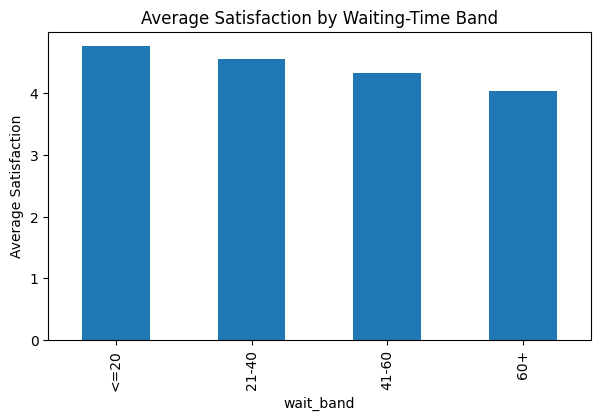

In [175]:
plt.figure(figsize=(7,4))
waiting_satisfaction.plot(kind='bar')
plt.title('Average Satisfaction by Waiting-Time Band')
plt.ylabel('Average Satisfaction')
plt.show()

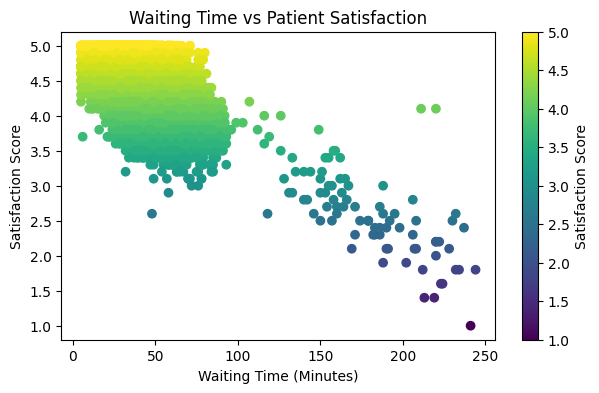

In [176]:
plt.figure(figsize=(7,4))
plt.scatter(
    df['waiting_time_minutes'],
    df['satisfaction_score'],
    c=df['satisfaction_score'],
    cmap='viridis'
)
plt.title('Waiting Time vs Patient Satisfaction')
plt.xlabel('Waiting Time (Minutes)')
plt.ylabel('Satisfaction Score')
plt.colorbar(label='Satisfaction Score')
plt.show()

#### Observation

Patients waiting 20 minutes or less have an average satisfaction score of approximately 4.76/5, while patients waiting more than 60 minutes have an average satisfaction score of approximately 4.04/5.

#### Insight

The results show a clear decline in average patient satisfaction as waiting time increases, indicating that longer waiting times are associated with a less positive patient experience.

#### Business Recommendation

Treat long waiting times as both an operational and patient-experience issue. Prioritize reducing the number of visits with 60+ minute waiting times through improved patient flow, scheduling, and queue management.

### Business Question9: Which insurance group has the highest average patient-paid amount from their own pocket?

In [177]:
insurance_payment = (
    df.groupby('insurance_status')
      .agg(avg_bill=('bill_amount','mean'),
           avg_patient_paid=('patient_paid_amount','mean'),
          avg_out_of_pocket_pct=('out_of_pocket_pct','mean')
      )
      .round(2)
)
display(insurance_payment)

,avg_bill,avg_patient_paid,avg_out_of_pocket_pct
insurance_status,,,
Government Scheme,6452.26,1140.69,17.89
Insured,6811.56,2105.32,31.54
Self Pay,6317.59,6299.56,99.91


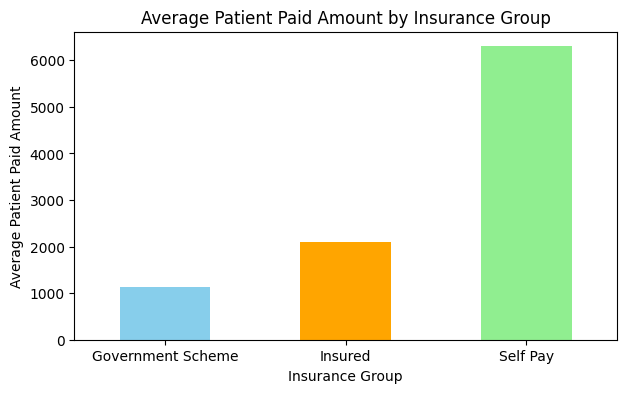

In [178]:
plt.figure(figsize=(7,4))
insurance_payment['avg_patient_paid'].plot(
    kind='bar',
    color=['skyblue', 'orange', 'lightgreen']
)
plt.title('Average Patient Paid Amount by Insurance Group')
plt.xlabel('Insurance Group')
plt.ylabel('Average Patient Paid Amount')
plt.xticks(rotation=0)

plt.show()

#### Observation

Self Pay patients have the highest average out-of-pocket share at approximately 99.9%, compared with 31.6% for Insured patients and 17.9% for Government Scheme patients.

#### Insight

Self-pay patients bear the largest direct financial burden, as they are responsible for almost the entire cost of their healthcare expenses.

#### Business Recommendation

Provide clear cost estimates, payment counselling, and flexible payment or installment options for patient groups with high out-of-pocket expenses to improve financial transparency and payment management.

### Business Question10: Which visit type has the highest average bill amount?

In [180]:
visit_type_billing = (
    df.groupby('visit_type')
      .agg(
          visits=('visit_id','count'),
          average_bill=('bill_amount','mean'),
          total_revenue=('bill_amount','sum')
      )
      .round(2)
)
display(visit_type_billing)

,visits,average_bill,total_revenue
visit_type,,,
Emergency,2195,4726.84,10375419.35
Inpatient,1733,28579.38,49528068.53
OPD,8117,2395.82,19446879.86


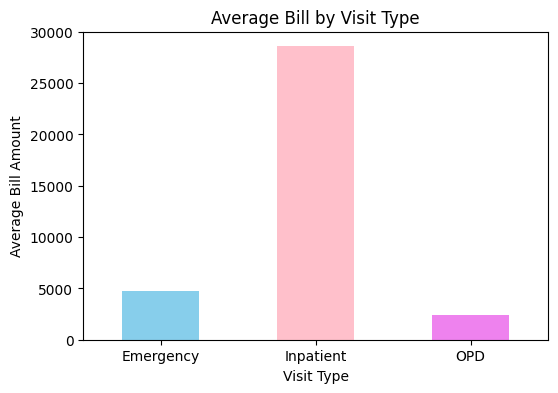

In [185]:
plt.figure(figsize=(6,4))
visit_type_billing['average_bill'].plot(
    kind='bar',
    color=['skyblue', 'pink', 'violet', 'violet']
)
plt.title('Average Bill by Visit Type')
plt.xlabel('Visit Type')
plt.ylabel('Average Bill Amount')
plt.xticks(rotation=0)
plt.show()

#### Observation

Inpatient visits have the highest average bill amount, at approximately ₹28,641 per visit, compared with other visit types.

#### Insight

Inpatient visits generate substantially higher revenue per visit, indicating greater financial impact and resource utilization compared with OPD and Emergency visits.

### Business Recommendation

Analyze inpatient capacity, length of stay, resource utilization, and payer mix separately, as inpatient services have different cost and revenue patterns compared with OPD and Emergency services.

### Business Question11: Which combination of age group and chronic condition accounts for the highest number of hospital visits?

In [186]:
age_chronic = (
    df[df['chronic_condition'] != 'None']
    .groupby(['age_group','chronic_condition'], observed=False)['patient_id']
    .nunique()
    .sort_values(ascending=False)
)
display(age_chronic.head(15))

age_group  chronic_condition
31-45      Nonevalue            607
46-60      Nonevalue            489
18-30      Nonevalue            300
60+        Nonevalue            237
           Hypertension         235
46-60      Hypertension         226
           Diabetes             204
60+        Diabetes             171
31-45      Diabetes             153
           Hypertension         145
0-17       Nonevalue            124
31-45      Asthma               102
46-60      Cardiac               96
60+        Cardiac               95
46-60      Asthma                86
Name: patient_id, dtype: int64

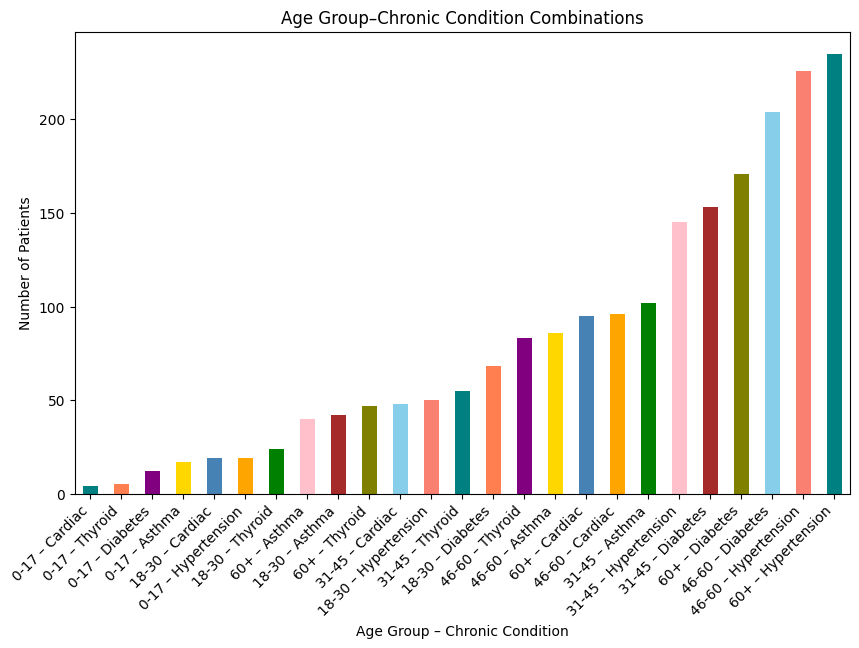

In [201]:
age_chronic_filtered = age_chronic[
    age_chronic.index.get_level_values('chronic_condition') != 'Nonevalue'
]
age_chronic_all = age_chronic_filtered.sort_values()
age_chronic_all.index = [
    f'{age} – {condition}'
    for age, condition in age_chronic_all.index
]
plt.figure(figsize=(10, 6))
age_chronic_all.plot(
    kind='bar',
    color=[
        'teal', 'coral', 'purple', 'gold',
        'steelblue', 'orange', 'green', 'pink',
        'brown', 'olive', 'skyblue', 'salmon'
    ]
)
plt.title('Age Group–Chronic Condition Combinations')
plt.xlabel('Age Group – Chronic Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation

The largest chronic-care segment is Hypertension among the 60+ age group, with approximately 235 unique patients.

#### Insight

Chronic-care demand is concentrated in specific age–condition combinations rather than being evenly distributed across all patient groups.

#### Business Recommendation

Develop targeted follow-up, screening, and monitoring programs for the highest-demand chronic-care segments, particularly patients with frequently observed conditions such as Hypertension and Diabetes.

## **PART C - MULTIVARIATE & DIAGNOSTIC ANALYSIS**

Multivariate and diagnostic analysis examines multiple variables together to understand more complex relationships, identify the factors contributing to operational and patient-care outcomes, and uncover potential business problems.

#### Business Question12: Which department and visit-type combination has the most serious waiting problem?

In [124]:
department_type = (
    df.groupby(['department','visit_type'])
      .agg(
          visits=('visit_id','count'),
          avg_wait=('waiting_time_minutes','mean'),
          avg_satisfaction=('satisfaction_score','mean')
      )
      .round(2)
      .sort_values(['avg_wait','visits'], ascending=[False,False])
)
display(department_type.head(15))

visits  avg_wait  avg_satisfaction
department       visit_type                                    
Cardiology       OPD           1318     61.58              4.17
                 Inpatient      262     57.17              4.22
General Medicine OPD           2388     52.31              4.30
Cardiology       Emergency      337     49.73              4.35
General Medicine Inpatient      497     48.15              4.35
Pulmonology      OPD           1129     46.72              4.36
Orthopedics      OPD           1329     43.16              4.42
Pulmonology      Inpatient      228     42.89              4.43
General Medicine Emergency      674     42.26              4.41
Gynecology       OPD            979     39.90              4.47
Orthopedics      Inpatient      305     39.55              4.49
Pediatrics       OPD            974     36.45              4.51
Pulmonology      Emergency      280     36.05              4.51
Gynecology       Inpatient      229     34.71              4.49
Pediatrics       Inpatient      212     31.78              4.56

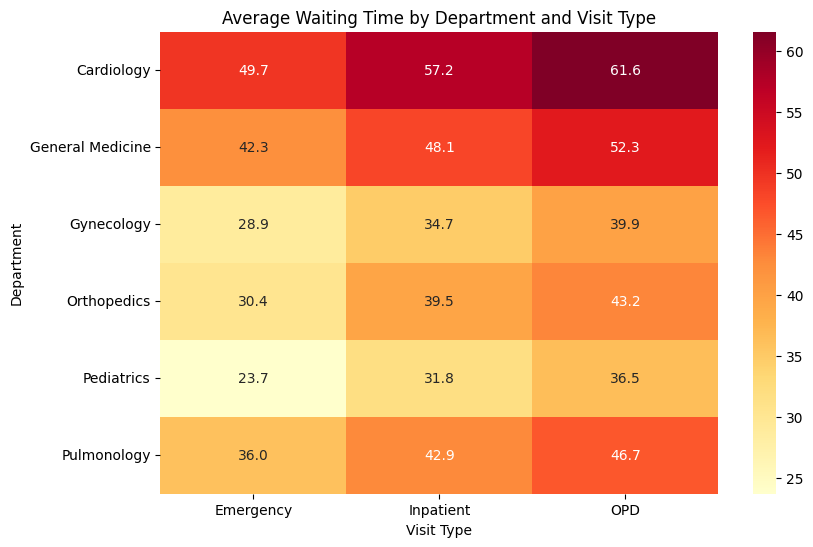

In [138]:
wait_heatmap = department_type['avg_wait'].unstack()
plt.figure(figsize=(9, 6))
sns.heatmap(
    wait_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)
plt.title('Average Waiting Time by Department and Visit Type')
plt.xlabel('Visit Type')
plt.ylabel('Department')
plt.show()

#### Observation

The most serious waiting-time combination is Cardiology – OPD, with an average waiting time of approximately 61.58 minutes and an average satisfaction score of 4.18/5.

#### Insight

The waiting-time issue is concentrated in a specific department–visit-type combination, rather than being a problem across the entire Cardiology department. This helps management focus on the specific service where operational pressure is highest.

#### Business Recommendation

Prioritize improvement efforts for Cardiology – OPD by reviewing appointment scheduling, patient flow, registration processes, and resource availability. Monitor waiting time and satisfaction for this specific combination to evaluate whether operational improvements are effective.

### Business Question13: During which months does the hospital experience the highest patient demand?

visit_day
Wednesday    1807
Sunday       1736
Monday       1726
Thursday     1708
Tuesday      1708
Saturday     1682
Friday       1678
Name: count, dtype: int64

visit_hour
12    1465
13    1464
11    1345
14    1330
10    1116
15    1095
9      865
16     844
Name: count, dtype: int64

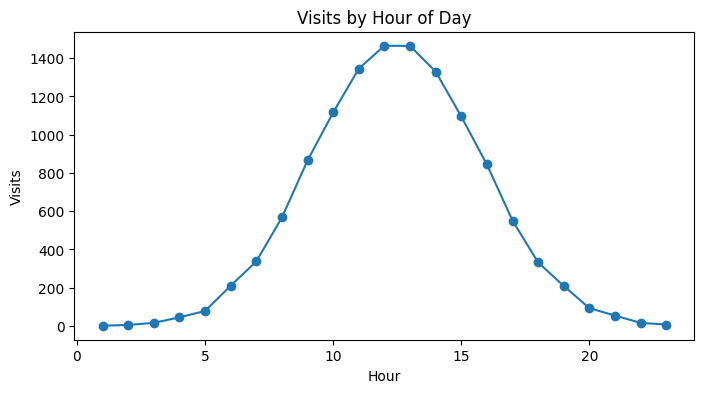

In [145]:
hour_analysis = df['visit_hour'].value_counts().sort_index()
day_analysis = df['visit_day'].value_counts()
display(day_analysis)
display(hour_analysis.sort_values(ascending=False).head(8))
plt.figure(figsize=(8,4))
hour_analysis.plot(kind='line', marker='o')
plt.title('Visits by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Visits')
plt.show()


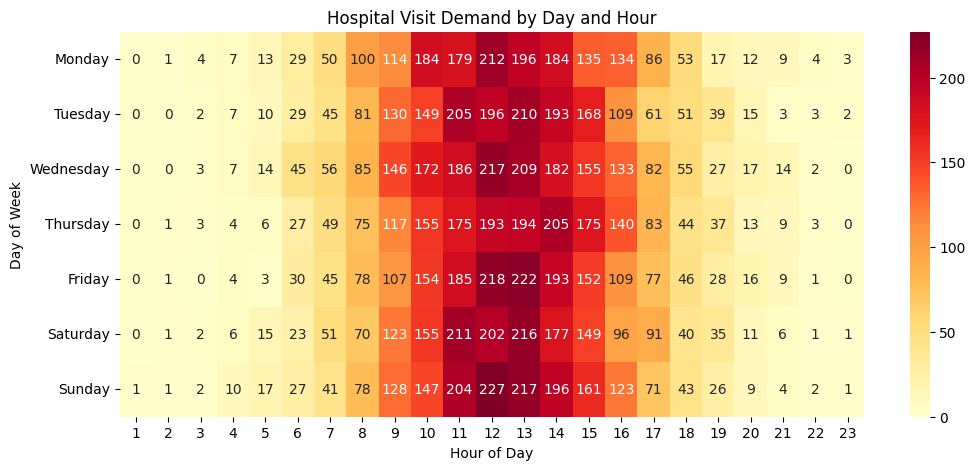

In [143]:
day_hour_analysis = pd.crosstab(
    df['visit_day'],
    df['visit_hour']
)
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
day_hour_analysis = day_hour_analysis.reindex(day_order)
plt.figure(figsize=(12, 5))
sns.heatmap(
    day_hour_analysis,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)
plt.title('Hospital Visit Demand by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

#### Observation

The highest patient demand occurs on Wednesday, 12:00 PM identified as the busiest hour followed by the next busiest hour occurs on Friday, 13: 00 PM and Sunday, 12: 00 PM.

#### Insight

Hospital demand is concentrated during specific days and time periods, indicating predictable peak-demand patterns.

#### Business Recommendation

Increase registration, nursing, and consultation support around recurring peak periods rather than maintaining the same staffing level across all hours. This can help manage patient flow and reduce operational pressure during high-demand periods.

### Business Question14: How important are repeat patients to the hospital, and what share of total visits comes from them?

In [146]:
repeat_analysis = (
    df.groupby('repeat_patient')
      .agg(
          unique_patients=('patient_id','nunique'),
          total_visits=('visit_id','count'),
          avg_bill=('bill_amount','mean'),
          avg_satisfaction=('satisfaction_score','mean')
      )
      .round(2)
)
display(repeat_analysis)

,unique_patients,total_visits,avg_bill,avg_satisfaction
repeat_patient,,,,
Repeat,3187,11429,6573.02,4.39
Single Visit,616,616,6862.50,4.38


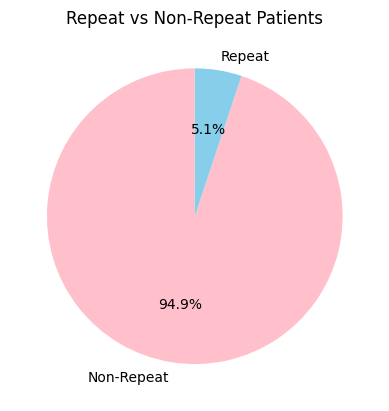

In [158]:
repeat_counts = df['repeat_patient'].value_counts()
plt.pie(
    repeat_counts,
    labels=['Non-Repeat', 'Repeat'],
    autopct='%1.1f%%',
    colors=['pink', 'skyblue'],
    startangle=90
)
plt.title('Repeat vs Non-Repeat Patients')
plt.show()

#### Observation

Approximately 83.8% of unique patients are repeat patients, with 3,187 repeat patients generating 11,429 visits. Single-visit patients account for 616 patients and 616 visits.

#### Insight

Repeat patients contribute a substantial share of overall hospital visits, indicating that repeat utilization is a major component of hospital demand.

#### Business Recommendation

Do not treat every repeat visit as a negative outcome. Differentiate planned chronic-care and follow-up visits from potentially avoidable repeat visits by examining diagnosis, visit type, and chronic conditions.

### Business Question15: Does patient satisfaction differ significantly between patients who experience low waiting times and high waiting times?

In [159]:
low_wait = df.loc[
    df['waiting_time_minutes'] <= 40,
    'satisfaction_score'
]
high_wait = df.loc[
    df['waiting_time_minutes'] > 60,
    'satisfaction_score'
]
t_stat, p_value = stats.ttest_ind(
    low_wait,
    high_wait,
    equal_var=False
)
print('Low-wait average satisfaction:', round(low_wait.mean(), 2))
print('High-wait average satisfaction:', round(high_wait.mean(), 2))
print('P-value:', p_value)

Low-wait average satisfaction: 4.59
High-wait average satisfaction: 4.04
P-value: 0.0


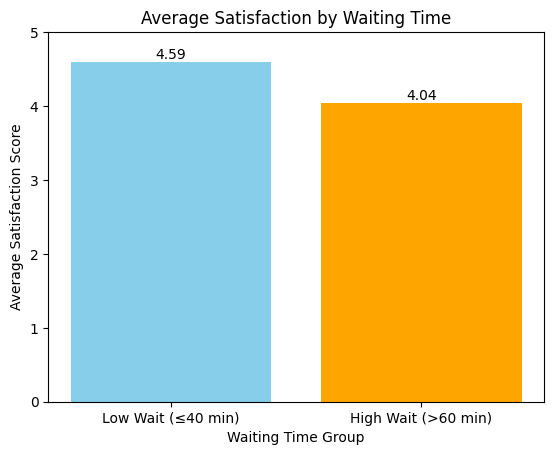

In [165]:
low_avg = low_wait.mean()
high_avg = high_wait.mean()
plt.bar(
    ['Low Wait (≤40 min)', 'High Wait (>60 min)'],
    [low_avg, high_avg],
    color=['skyblue', 'orange']
)
plt.title('Average Satisfaction by Waiting Time')
plt.xlabel('Waiting Time Group')
plt.ylabel('Average Satisfaction Score')
plt.ylim(0, 5)
plt.text(0, low_avg + 0.05, f'{low_avg:.2f}', ha='center')
plt.text(1, high_avg + 0.05, f'{high_avg:.2f}', ha='center')
plt.show()

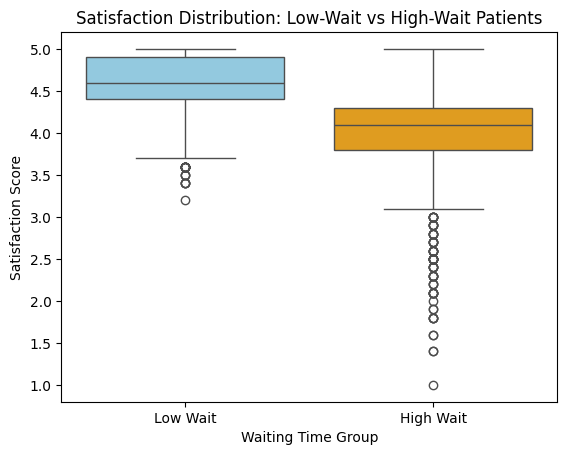

In [166]:
sns.boxplot(
    x=['Low Wait'] * len(low_wait) + ['High Wait'] * len(high_wait),
    y=list(low_wait) + list(high_wait),
    palette=['skyblue', 'orange'],
    hue=['Low Wait'] * len(low_wait) + ['High Wait'] * len(high_wait),
    legend=False
)
plt.title('Satisfaction Distribution: Low-Wait vs High-Wait Patients')
plt.xlabel('Waiting Time Group')
plt.ylabel('Satisfaction Score')
plt.show()

#### Observation

Patients with low waiting times (≤40 minutes) had an average satisfaction score of 4.59, compared with 4.04 for patients with high waiting times (>60 minutes).

The p-value is approximately 0.0 (effectively below 0.001), indicating that the difference is statistically significant.

#### Insight

The results provide strong statistical evidence of a difference in satisfaction between the low-wait and high-wait groups. In this dataset, higher waiting times are associated with lower average patient satisfaction.

#### Business Recommendation

Prioritize reducing excessive waiting times, particularly for patients waiting more than 60 minutes, while monitoring whether improvements in waiting time are accompanied by improvements in patient satisfaction.

### PART D – FINAL MANAGEMENT STORY
**
What the Analysis Tells Us**
Patient demand is concentrated in specific age groups and chronic conditions.
Cardiology experiences the strongest waiting-time pressure.
General Medicine handles the highest overall visit volume.
Patient satisfaction decreases as waiting time increases.
Self-pay patients bear almost the entire bill amount themselves.
Inpatient services have the highest average billing value.
Patient demand peaks at identifiable days and hours.
Repeat patients represent a major share of hospital utilization.

### Final Business Recommendations
#### 1. Improve Cardiology OPD Flow

Review doctor scheduling, appointment slots, registration processes, and patient flow to reduce waiting-time pressure.

#### 2. Create a Waiting-Time KPI

Track the following metrics regularly:
Average waiting time
Median waiting time
Percentage of patients waiting more than 60 minutes

#### 3. Align Staffing With Demand

Use day-level and hourly visit patterns to align staffing and resources with periods of higher patient demand.

#### 4. Improve Chronic-Care Follow-Up

Create focused follow-up workflows for high-utilization age and condition groups, while distinguishing planned follow-up visits from potentially avoidable repeat visits.

#### 5. Reduce Patient Financial Stress

Improve cost communication and provide appropriate payment options for self-pay patients.

#### 6. Monitor Patient Experience Alongside Operations

Track patient satisfaction together with waiting-time performance rather than treating patient experience and operational performance as separate measures.

# Interview-Ready Project Explanation

“I worked on an end-to-end healthcare analytics project using three tables: Patients, Visits, and Billing. I started by understanding the business problems and auditing the data quality.

For missing and invalid values, I used business context rather than blindly applying mean or median imputation. For example, I used chronic condition to support age imputation, age group for BMI, diagnosis to support department imputation, department and visit type for waiting time, waiting-time bands for satisfaction, and payer-related rules for insurance coverage.

After cleaning and merging the data, I performed univariate, bivariate, and multivariate analysis. For each analysis, I followed a business-driven approach: I first defined a business question, created the relevant table or visualization, identified the actual result, converted it into a business insight, and then suggested a practical business action.

Finally, I used a statistical t-test to check whether the difference in satisfaction between low-wait and high-wait patients was statistically significant. This helped me support the business finding with statistical evidence rather than relying only on visualization.”